# **P679-Hourly Consumpition Forecast.**

##Business Objective:

####PJM Hourly Energy Consumption Data
  PJM Interconnection LLC (PJM) is a regional transmission organization (RTO) in the United States. It is part of the Eastern Interconnection grid operating an electric transmission system serving all or parts of Delaware, Illinois, Indiana, Kentucky, Maryland, Michigan, New Jersey, North Carolina, Ohio, Pennsylvania, Tennessee, Virginia, West Virginia, and the District of Columbia.

#####  The hourly power consumption data comes from PJM's website and are in megawatts (MW).The regions have changed over the years so data may only appear for certain dates per region.


In [ ]:
#Importing all required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [ ]:
# DIsplaying the first five rows of the dataset.
df = pd.read_excel("PJMW_MW_Hourly.xlsx")

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (143206, 2)


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [ ]:
#DIsplaying the columm names.
print("\nColumn Names:")
print(df.columns.tolist())



Column Names:
['Datetime', 'PJMW_MW']


### DATA UNDERSTANDING

In [ ]:
# Information of the Dataset.
print("\nDataset Information:")
df.info()




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [ ]:
# Statistical summery of the Dataset.
print("\nStatistical Summary:")
display(df.describe())



Statistical Summary:


,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


### DATA CLEANING

In [ ]:
#Checking the missing values.
print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing_Count"))

#printing the missing values and percentages.
print("\nMissing Value Percentage:")
display(
    (df.isnull().sum() / len(df) * 100)
    .round(2)
    .to_frame("Missing_Percentage")
)


Missing Values:


,Missing_Count
Datetime,0
PJMW_MW,0



Missing Value Percentage:


,Missing_Percentage
Datetime,0.0
PJMW_MW,0.0


In [ ]:
#Checking the duplicates.
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [ ]:
#Converting the Datetime column into DateTime formate.
#Invalid date values are converted to NaT.
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)
#COnverting PJMW_MW column into numeric format.
#invalid values are converted to NaN.
df["PJMW_MW"] = pd.to_numeric(
    df["PJMW_MW"],
    errors="coerce"
)

# Removing rows with missing or invalid values.
# in the essential Datetime and PJMW_MN.
df = df.dropna(
    subset=["Datetime", "PJMW_MW"]
)

In [ ]:
# DIsplaying the shape after cleaning.
df = df.sort_values("Datetime").reset_index(drop=True)

print("\nShape After Cleaning:", df.shape)


Shape After Cleaning: (143206, 2)


In [ ]:
print("\nStart Date:", df["Datetime"].min())
print("End Date:", df["Datetime"].max())


Start Date: 2002-04-01 01:00:00
End Date: 2018-08-03 00:00:00


In [ ]:
#checking the duplivcates in the Datetime column.
print(
    "\nDuplicate Datetime Values:",
    df["Datetime"].duplicated().sum()
)



Duplicate Datetime Values: 4


In [ ]:
# Checking duplicate datetime records
duplicate_datetime = df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime")

display(duplicate_datetime)

,Datetime,PJMW_MW
110327,2014-11-02 02:00:00,4571
110328,2014-11-02 02:00:00,4613
119063,2015-11-01 02:00:00,3927
119064,2015-11-01 02:00:00,3832
127967,2016-11-06 02:00:00,4114
127968,2016-11-06 02:00:00,4089
136703,2017-11-05 02:00:00,3984
136704,2017-11-05 02:00:00,4042


In [ ]:
# Checking whether duplicate timestamps have different consumption values
duplicate_datetime.groupby("Datetime")["PJMW_MW"].agg(["count", "min", "max"])

,count,min,max
Datetime,,,
2014-11-02 02:00:00,2,4571,4613
2015-11-01 02:00:00,2,3832,3927
2016-11-06 02:00:00,2,4089,4114
2017-11-05 02:00:00,2,3984,4042


In [ ]:
df = df.drop_duplicates(subset=["Datetime"], keep="first").reset_index(drop=True)

print("Shape after removing duplicate timestamps:", df.shape)

Shape after removing duplicate timestamps: (143202, 2)


In [ ]:
#Creating a complete hourly datetime range
#form the first avilable timestamp to the last avilable timrstamp.
full_dates = pd.date_range(                              #pd.date_range()-creates every ecpected hourly timestamp.
    start=df["Datetime"].min(),
    end=df["Datetime"].max(),
    freq="h"
)
#Find timestamps that are expected but missing from the dataset.
missing_hours = full_dates.difference(                   #difference()-Compares thise expected timestamps with actual Datatime values.
    df["Datetime"]
)
#Displaying the total number of expected hourly records.
print(
    "Expected Hourly Records:",
    len(full_dates)
)
#Displyaing the number of missing hourly records.
print(
    "Missing Hourly Records:",
    len(missing_hours)                                    #missing_hours - COntains the timestamps that are missing.
)
# If missing timestamps exist,display the first 20
if len(missing_hours) > 0:                                #tells how many hourly records are missing.
    print("\nFirst 20 Missing Timestamps:")
    print(missing_hours[:20])


Expected Hourly Records: 143232
Missing Hourly Records: 30

First 20 Missing Timestamps:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00',
               '2007-03-11 03:00:00', '2007-11-04 02:00:00',
               '2008-03-09 03:00:00', '2008-11-02 02:00:00',
               '2009-03-08 03:00:00', '2009-11-01 02:00:00',
               '2010-03-14 03:00:00', '2010-11-07 02:00:00',
               '2010-12-10 00:00:00', '2011-03-13 03:00:00'],
              dtype='datetime64[ns]', freq=None)


### MISSING TIMESTAMPS ANALYSIS

In [ ]:
# Handeling the missing hourly timestamps.
# Display all missing hourly timestamps
print("Missing hourly timestamps:")
display(pd.DataFrame({"Missing_Datetime": missing_hours}))

Missing hourly timestamps:


,Missing_Datetime
0,2002-04-07 03:00:00
1,2002-10-27 02:00:00
2,2003-04-06 03:00:00
3,2003-10-26 02:00:00
4,2004-04-04 03:00:00
5,2004-10-31 02:00:00
6,2005-04-03 03:00:00
7,2005-10-30 02:00:00
8,2006-04-02 03:00:00
9,2006-10-29 02:00:00


### Missing Timestamp Observation

A total of 30 hourly timestamps are missing from the dataset. Most missing timestamps correspond to daylight-saving-time transitions, where certain local clock hours may not exist or may be repeated. One additional non-DST timestamp was also identified and should be treated as a source-data gap rather than automatically imputed. Therefore, the missing timestamps are retained as a documented characteristic of the original dataset, and artificial target values are not created.*italicized text*

In [ ]:
# Display missing timestamps with date-related information
missing_check = pd.DataFrame({
    "Datetime": missing_hours
})

missing_check["Year"] = missing_check["Datetime"].dt.year
missing_check["Month"] = missing_check["Datetime"].dt.month
missing_check["Day"] = missing_check["Datetime"].dt.day
missing_check["Hour"] = missing_check["Datetime"].dt.hour

display(missing_check)

,Datetime,Year,Month,Day,Hour
0,2002-04-07 03:00:00,2002,4,7,3
1,2002-10-27 02:00:00,2002,10,27,2
2,2003-04-06 03:00:00,2003,4,6,3
3,2003-10-26 02:00:00,2003,10,26,2
4,2004-04-04 03:00:00,2004,4,4,3
5,2004-10-31 02:00:00,2004,10,31,2
6,2005-04-03 03:00:00,2005,4,3,3
7,2005-10-30 02:00:00,2005,10,30,2
8,2006-04-02 03:00:00,2006,4,2,3
9,2006-10-29 02:00:00,2006,10,29,2


In [ ]:
# Sorting data chronologically
df = df.sort_values("Datetime").reset_index(drop=True)

# Checking chronological order
print("Data sorted chronologically:", df["Datetime"].is_monotonic_increasing)

# Checking duplicate timestamps again
print("Duplicate timestamps:", df["Datetime"].duplicated().sum())

Data sorted chronologically: True
Duplicate timestamps: 0


### FEATURE ENGINEERING

In [ ]:
# Creating lag features using previous values

df["Lag_1_Hour"] = df["PJMW_MW"].shift(1)
df["Lag_24_Hours"] = df["PJMW_MW"].shift(24)
df["Lag_48_Hours"] = df["PJMW_MW"].shift(48)
df["Lag_168_Hours"] = df["PJMW_MW"].shift(168)

# Creating rolling features using only previous values

df["Rolling_24H"] = df["PJMW_MW"].shift(1).rolling(24).mean()
df["Rolling_7D"] = df["PJMW_MW"].shift(1).rolling(168).mean()

print("Lag and rolling features created successfully.")

Lag and rolling features created successfully.


In [ ]:
# Removing rows with missing lag and rolling values

lag_rolling_cols = [
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

df = df.dropna(subset=lag_rolling_cols).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())

Dataset shape: (143034, 8)
Total missing values: 0


In [ ]:
# Checking missing values after lag and rolling feature creation

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_summary)

,Missing_Count,Missing_Percentage
Datetime,0,0.0
PJMW_MW,0,0.0
Lag_1_Hour,0,0.0
Lag_24_Hours,0,0.0
Lag_48_Hours,0,0.0
Lag_168_Hours,0,0.0
Rolling_24H,0,0.0
Rolling_7D,0,0.0


In [ ]:
# Removing rows with missing lag/rolling features

required_features = [
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

df = df.dropna(subset=required_features).reset_index(drop=True)

print("Shape after removing lag/rolling NaN rows:", df.shape)

Shape after removing lag/rolling NaN rows: (143034, 8)


In [ ]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [ ]:
#Extract the year from the datetime column.
df["Year"] = df["Datetime"].dt.year

#Extract the month number(1-12).
df["Month"] = df["Datetime"].dt.month

#Extract the month name.
df["Month_Name"] = df["Datetime"].dt.month_name()

#Extract the day of the month.
df["Day"] = df["Datetime"].dt.day

#extract the hour of the day.
df["Hour"] = df["Datetime"].dt.hour

#Extract the day of the week(Monday=0,sunday = 6)
df["Day_of_Week"] = df["Datetime"].dt.dayofweek

#Extract the day Name.
df["Day_Name"] = df["Datetime"].dt.day_name()

#Extract the quater of the year.
df["Quarter"] = df["Datetime"].dt.quarter

#Extract the iSO week number.
df["Week"] = df["Datetime"].dt.isocalendar().week.astype(int)

# Identifies whether the day is a weekend
#Saturday = 5 and sunday =6
df["Weekend"] = df["Day_of_Week"] >= 5

In [ ]:
# Define a function to assign a seasin based on the month.
def get_season(month):

#December,January,february are classified as winter.
    if month in [12, 1, 2]:
        return "Winter"
#March,April,May are classified as spring.
    elif month in [3, 4, 5]:
        return "Spring"
#June,July,August are classified as Summer.
    elif month in [6, 7, 8]:
        return "Summer"
#September,October,November are classified as Autum.
    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

display(df.head())

,Datetime,PJMW_MW,Lag_1_Hour,Lag_24_Hours,Lag_48_Hours,Lag_168_Hours,Rolling_24H,Rolling_7D,Year,Month,Month_Name,Day,Hour,Day_of_Week,Day_Name,Quarter,Week,Weekend,Season
0,2002-04-08 02:00:00,4532,4634.0,5002.0,5082.0,4374.0,5029.625000,5379.339286,2002,4,April,8,2,0,Monday,2,15,False,Spring
1,2002-04-08 03:00:00,4481,4532.0,4858.0,4992.0,4306.0,5010.041667,5380.279762,2002,4,April,8,3,0,Monday,2,15,False,Spring
2,2002-04-08 04:00:00,4527,4481.0,4871.0,4932.0,4322.0,4994.333333,5381.321429,2002,4,April,8,4,0,Monday,2,15,False,Spring
3,2002-04-08 05:00:00,4640,4527.0,4909.0,4956.0,4359.0,4980.000000,5382.541667,2002,4,April,8,5,0,Monday,2,15,False,Spring
4,2002-04-08 06:00:00,4940,4640.0,5038.0,4997.0,4436.0,4968.791667,5384.214286,2002,4,April,8,6,0,Monday,2,15,False,Spring


### Exploratory Data Analysis (EDA)

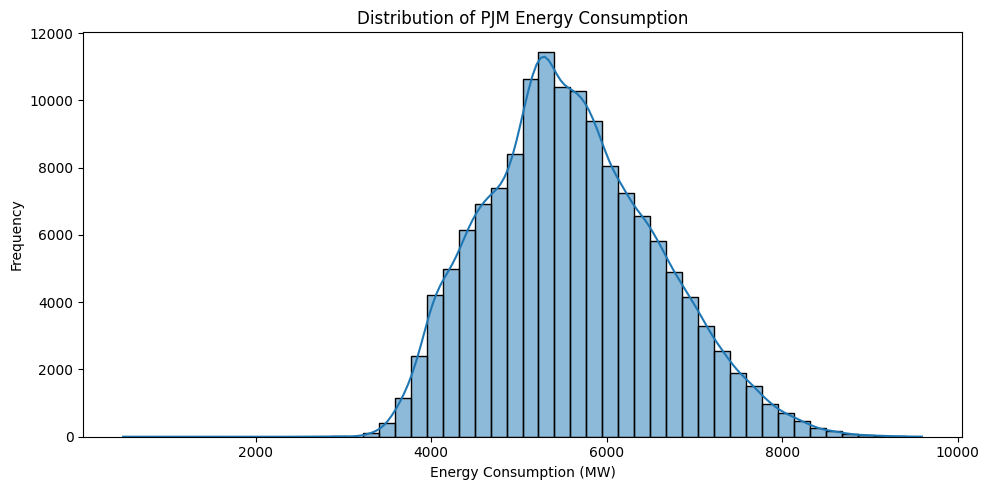

In [ ]:
#Plotting the histogram for the (Frequency/Energy Consumption (MW))
plt.figure(figsize=(10, 5))

sns.histplot(
    df["PJMW_MW"],
    bins=50,
    kde=True
)

plt.title("Distribution of PJM Energy Consumption")
plt.xlabel("Energy Consumption (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#### INFERENCE:
The PJM energy consumption distribution is unimodal and slightly right-skewed. Most observations are concentrated around 4,000 to 7,000 MW, with peak frequency around 5,000–5,500 MW. Extremely high and low consumption values occur less frequently.”

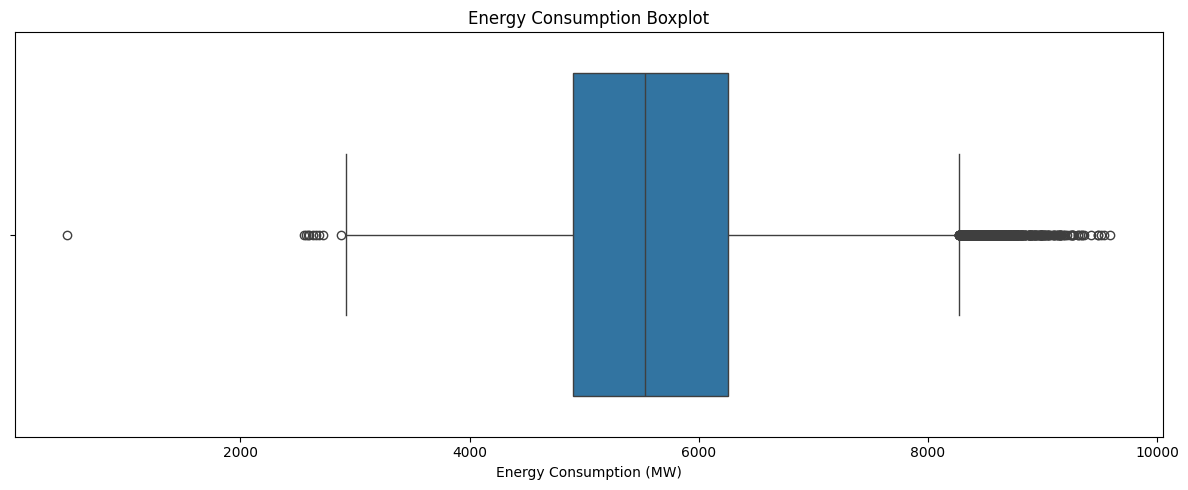

In [ ]:
##Plotting the Boxplot for (Energy Consumption (MW))
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df["PJMW_MW"]
)

plt.title("Energy Consumption Boxplot")
plt.xlabel("Energy Consumption (MW)")

plt.tight_layout()
plt.show()


### INFERENCE:
The boxplot shows that PJM energy consumption is mainly concentrated between approximately 4,800 and 6,300 MW, with a median around 5,500 MW. There are several potential outliers, particularly on the higher side, indicating periods of unusually high energy consumption. A few low-end outliers are also present. These extreme values should be investigated to determine whether they represent genuine peak-demand periods or data anomalies.

### Outlier Analysis and Treatment

In [ ]:
#OUTLIER DETEECTION USING THE (IQR).
#Calculates the first and third quartile(25th percentile, 75th percentile)
Q1 = df["PJMW_MW"].quantile(0.25)
Q3 = df["PJMW_MW"].quantile(0.75)

#Calculates the interquartile Range.
IQR = Q3 - Q1

#Calculates the lower and upper limits for detecting outliers.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Identify observations below the lower bound  or above the upper bound as potential outliers.
outliers = df[
    (df["PJMW_MW"] < lower_bound) |
    (df["PJMW_MW"] > upper_bound)
]

#Displays the calculated outliers boundries.
print("\nIQR Lower Bound:", lower_bound)
print("IQR Upper Bound:", upper_bound)

#Displays the number of potential outliers.
print("Potential Outliers:", len(outliers))



IQR Lower Bound: 2885.5
IQR Upper Bound: 8273.5
Potential Outliers: 695


###Outlier Treatment:
Potential outliers were identified using the IQR method. Since electricity consumption can naturally exhibit high-demand and low-demand periods, these observations were retained because extreme values may represent genuine peak demand rather than data errors.

#### INFERENCE:
The IQR method was used to identify potential outliers in PJM energy consumption. The observations outside the calculated lower and upper bounds are flagged as potential outliers. These values may represent periods of unusually high or low electricity demand, so they should be investigated rather than removed automatically.

### ADF TEST

In [ ]:
## ADF Stationarity Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
adf_result = adfuller(df["PJMW_MW"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations Used:", adf_result[3])

if adf_result[1] <= 0.05:
    print("\nResult: The series is stationary.")
else:
    print("\nResult: The series is non-stationary.")

ADF Statistic: -19.881056637387857
p-value: 0.0
Number of Lags Used: 74
Number of Observations Used: 142959

Result: The series is stationary.


/tmp/ipykernel_3378/1110407065.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df["PJMW_MW"].dropna())


## **Time-Series Stationarity Analysis**

### ACF Analysis

<Figure size 1200x500 with 0 Axes>

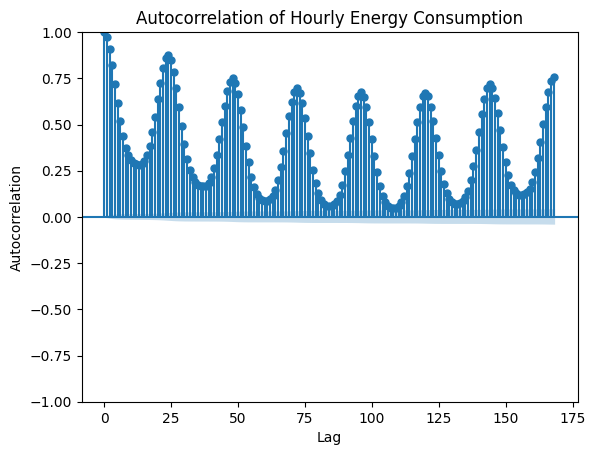

In [ ]:
#importing the plot_acf from statsmodels.graphics.tsaplots
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    df["PJMW_MW"].dropna(),
    lags=168
)

plt.title("Autocorrelation of Hourly Energy Consumption")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

### PACF Analysis

<Figure size 1200x500 with 0 Axes>

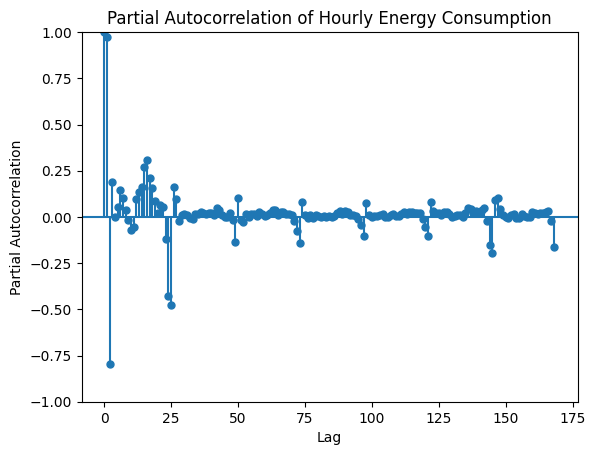

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 5))

plot_pacf(
    df["PJMW_MW"].dropna(),
    lags=168,
    method="ywm"
)

plt.title("Partial Autocorrelation of Hourly Energy Consumption")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

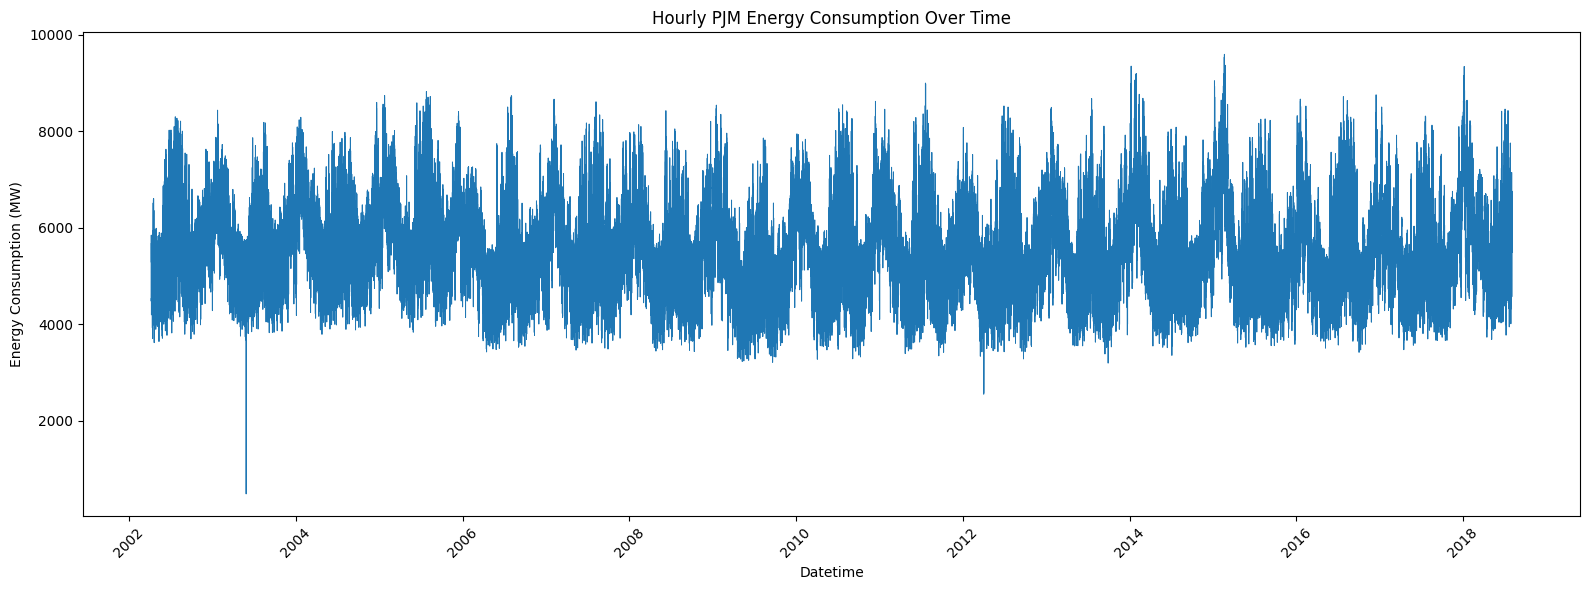

In [ ]:
#plotting the time series  line plot.
plt.figure(figsize=(16, 6))

plt.plot(
    df["Datetime"],
    df["PJMW_MW"],
    linewidth=0.7
)

plt.title("Hourly PJM Energy Consumption Over Time")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### INFERENCE:
The time-series plot shows that PJM energy consumption has a clear recurring pattern with frequent fluctuations throughout the period. Consumption generally ranges between approximately 4,000 and 8,000 MW, with occasional peaks reaching around 9,000–10,000 MW. The repeated patterns suggest strong seasonal and daily variations in electricity demand. Overall, there is no clear long-term upward or downward trend, while some extreme peaks and dips indicate periods of unusually high or low consumption.


Average Consumption by Hour:


,Average_Consumption_MW
Hour,
0,5230.544631
1,4940.632718
2,4779.598084
3,4697.112363
4,4672.453447
5,4734.841973
6,4958.053682
7,5323.287032
8,5571.048314


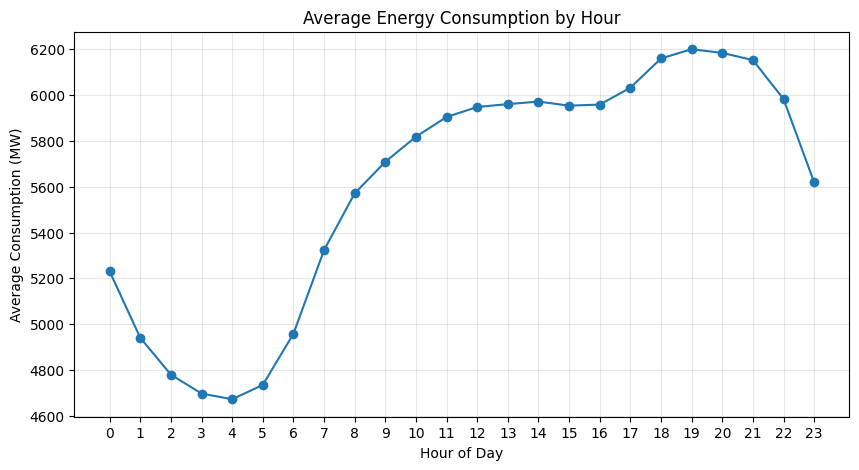

In [ ]:
#Hourly average energy consumption plot.
hourly_avg = (
    df.groupby("Hour")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Hour:")
display(
    hourly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MW)")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()


### INDERENCE:
The plot shows a clear daily pattern in energy consumption. Consumption is lowest during the early morning hours, reaching its minimum around 4 AM. It then steadily increases through the morning and reaches a high level during the afternoon and evening. The peak occurs around 7–8 PM, after which consumption decreases, with a noticeable drop during the late evening. This indicates strong daily/diurnal seasonality in electricity demand.


Average Consumption by Day:


,Average_Consumption_MW
Day_Name,
Monday,5701.098063
Tuesday,5801.652729
Wednesday,5802.929920
Thursday,5780.970217
Friday,5686.840041
Saturday,5293.912701
Sunday,5149.935870


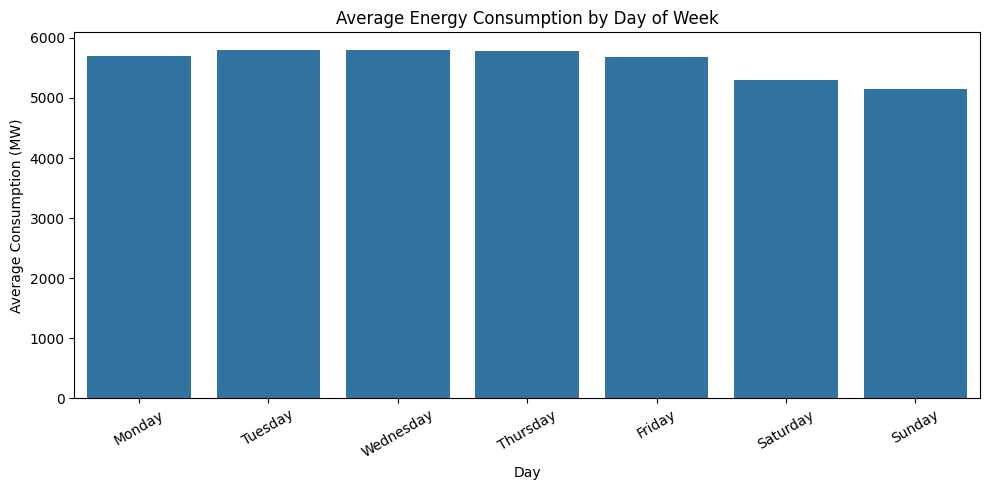

In [ ]:
#Plotting bar chart for average PJM energy consumption by day of the week.
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_avg = (
    df.groupby("Day_Name")["PJMW_MW"]
    .mean()
    .reindex(day_order)
)

print("\nAverage Consumption by Day:")
display(
    day_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_avg.index,
    y=day_avg.values
)

plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Consumption (MW)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()


### INFERENCE:
The chart shows that average energy consumption is relatively consistent from Monday to Friday, with Wednesday and Thursday having slightly higher consumption. Consumption decreases noticeably on Saturday and Sunday. This indicates a weekly pattern, where energy demand is generally higher on weekdays and lower during weekends.

Weekday Average: 5754.7151760032875
Weekend Average: 5221.973664870162


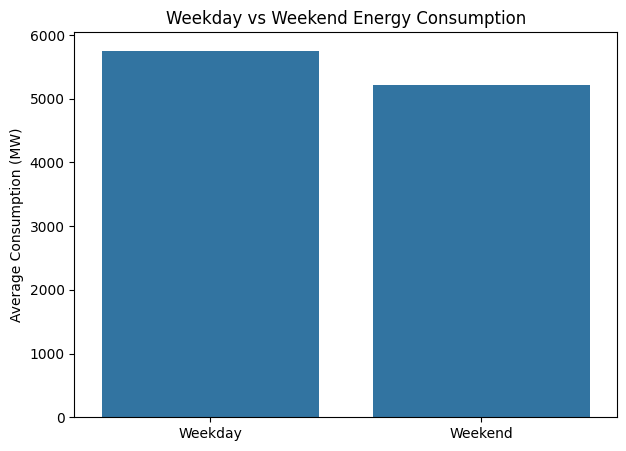

In [ ]:
#plotting Comparission plot by bar chart.
weekend_avg = (
    df.groupby("Weekend")["PJMW_MW"]
    .mean()
)

print(
    "Weekday Average:",
    weekend_avg.get(False, np.nan)
)

print(
    "Weekend Average:",
    weekend_avg.get(True, np.nan)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=["Weekday", "Weekend"],
    y=[
        weekend_avg.get(False, np.nan),
        weekend_avg.get(True, np.nan)
    ]
)

plt.title("Weekday vs Weekend Energy Consumption")
plt.ylabel("Average Consumption (MW)")

plt.show()


### INFERENCE:
The chart shows that average energy consumption is higher on weekdays, at approximately 5,750 MW, compared with around 5,200 MW on weekends. This indicates that electricity demand is higher during weekdays and decreases during weekends, showing a clear weekday–weekend consumption pattern.


Average Consumption by Month:


,Average_Consumption_MW
Month,
1,6447.667759
2,6296.808813
3,5654.097376
4,5017.339798
5,5015.845746
6,5516.756046
7,5861.537081
8,5822.142809
9,5205.872049


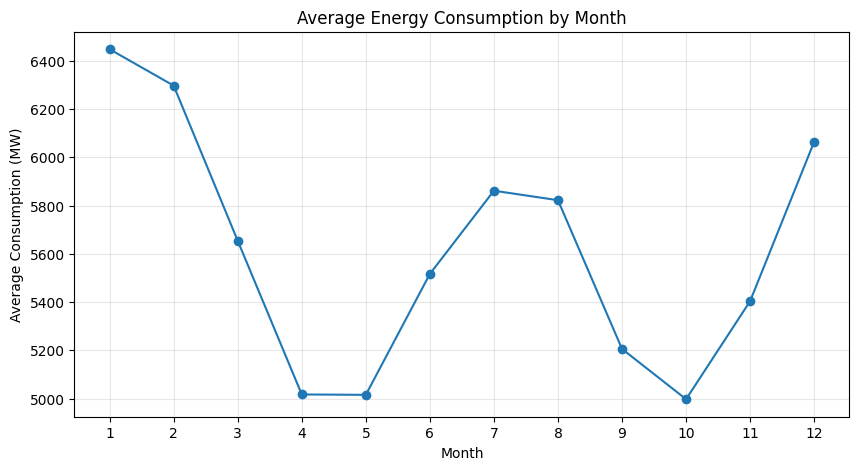

In [ ]:
monthly_avg = (
    df.groupby("Month")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Month:")
display(
    monthly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Consumption (MW)")

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.show()


### INFERNEC:
Energy consumption varies considerably across months. It is highest in January and December, while it reaches lower levels around April–May and October, indicating a clear monthly/seasonal pattern in electricity demand.


Average Consumption by Year:


,Average_Consumption_MW
Year,
2002,5627.995489
2003,5700.628226
2004,5866.616602
2005,6038.406029
2006,5425.448847
2007,5635.396780
2008,5530.132544
2009,5290.557433
2010,5573.025351


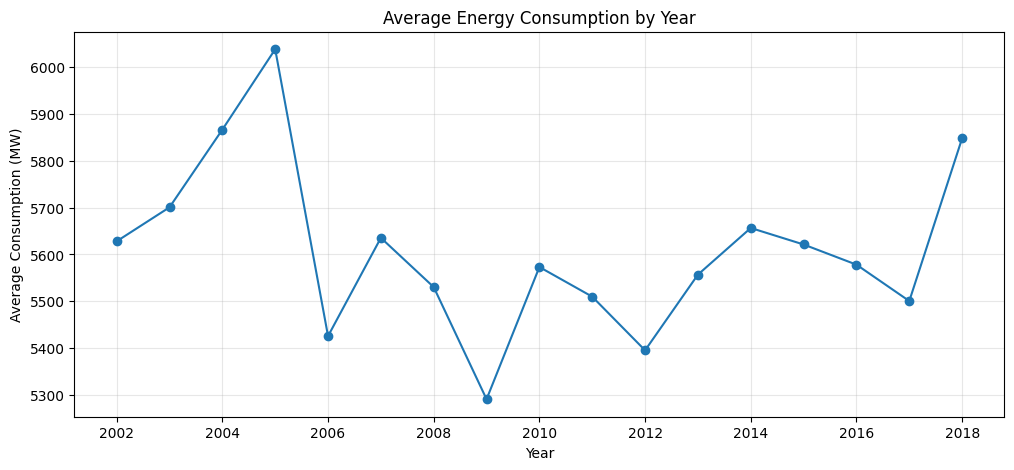

In [ ]:


yearly_avg = (
    df.groupby("Year")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Year:")
display(
    yearly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(12, 5))

plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Year")
plt.xlabel("Year")
plt.ylabel("Average Consumption (MW)")

plt.grid(True, alpha=0.3)

plt.show()

#### INFERENCE:
The yearly average shows noticeable fluctuations rather than a consistent upward or downward trend. Consumption peaks around 2005, declines afterward, and fluctuates through the later years, with an increase again in 2018.


Average Consumption by Season:


,Average_Consumption_MW
Season,
Winter,6268.813851
Spring,5223.683686
Summer,5734.206129
Autumn,5200.264085


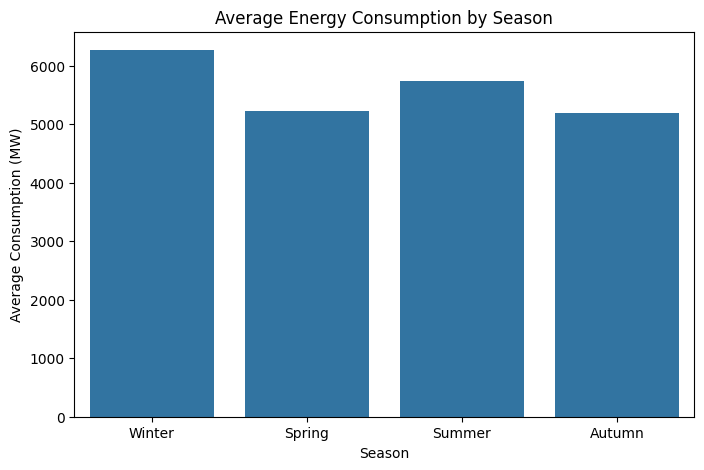

In [ ]:

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

season_avg = (
    df.groupby("Season")["PJMW_MW"]
    .mean()
    .reindex(season_order)
)

print("\nAverage Consumption by Season:")
display(
    season_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_avg.index,
    y=season_avg.values
)

plt.title("Average Energy Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Average Consumption (MW)")

plt.show()


#### INFERENCE:
Winter has the highest average energy consumption, followed by summer. Spring and autumn show comparatively lower consumption. This indicates that seasonal conditions have a significant influence on electricity demand.

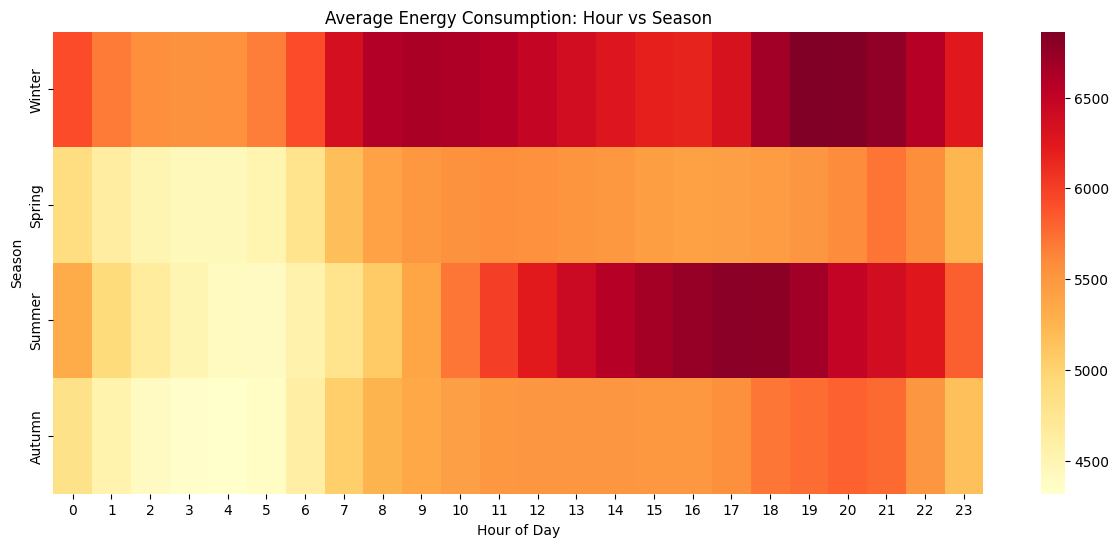

In [ ]:
hour_season = df.pivot_table(
    values="PJMW_MW",
    index="Season",
    columns="Hour",
    aggfunc="mean"
)

hour_season = hour_season.reindex(
    season_order
)

plt.figure(figsize=(15, 6))

sns.heatmap(
    hour_season,
    cmap="YlOrRd"
)

plt.title(
    "Average Energy Consumption: Hour vs Season"
)

plt.xlabel("Hour of Day")
plt.ylabel("Season")

plt.show()


#### INFERENCE:
Energy consumption varies by both hour of the day and season. Winter generally shows higher consumption, particularly during later hours, while spring and autumn have relatively lower levels. This indicates an interaction between seasonal and daily demand patterns.

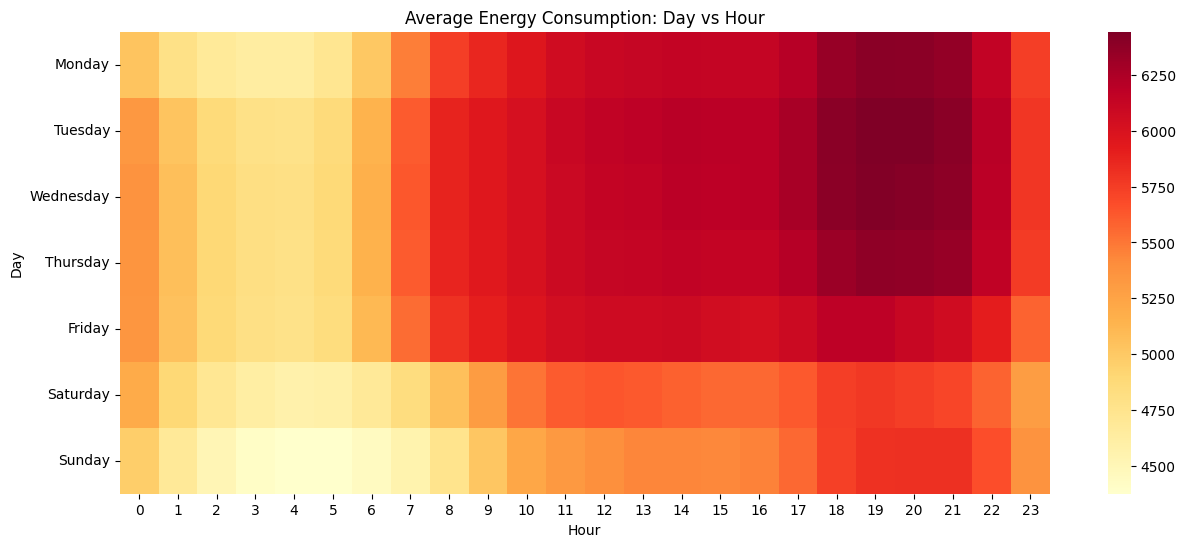

In [ ]:
day_hour = df.pivot_table(
    values="PJMW_MW",
    index="Day_Name",
    columns="Hour",
    aggfunc="mean"
)

day_hour = day_hour.reindex(
    day_order
)

plt.figure(figsize=(15, 6))

sns.heatmap(
    day_hour,
    cmap="YlOrRd"
)

plt.title(
    "Average Energy Consumption: Day vs Hour"
)

plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

### INFERENCE:
Energy consumption is generally lower during the early morning hours and increases from around 7–8 AM. It remains high throughout the daytime and evening, with particularly high consumption on weekdays. Weekend consumption is comparatively lower.

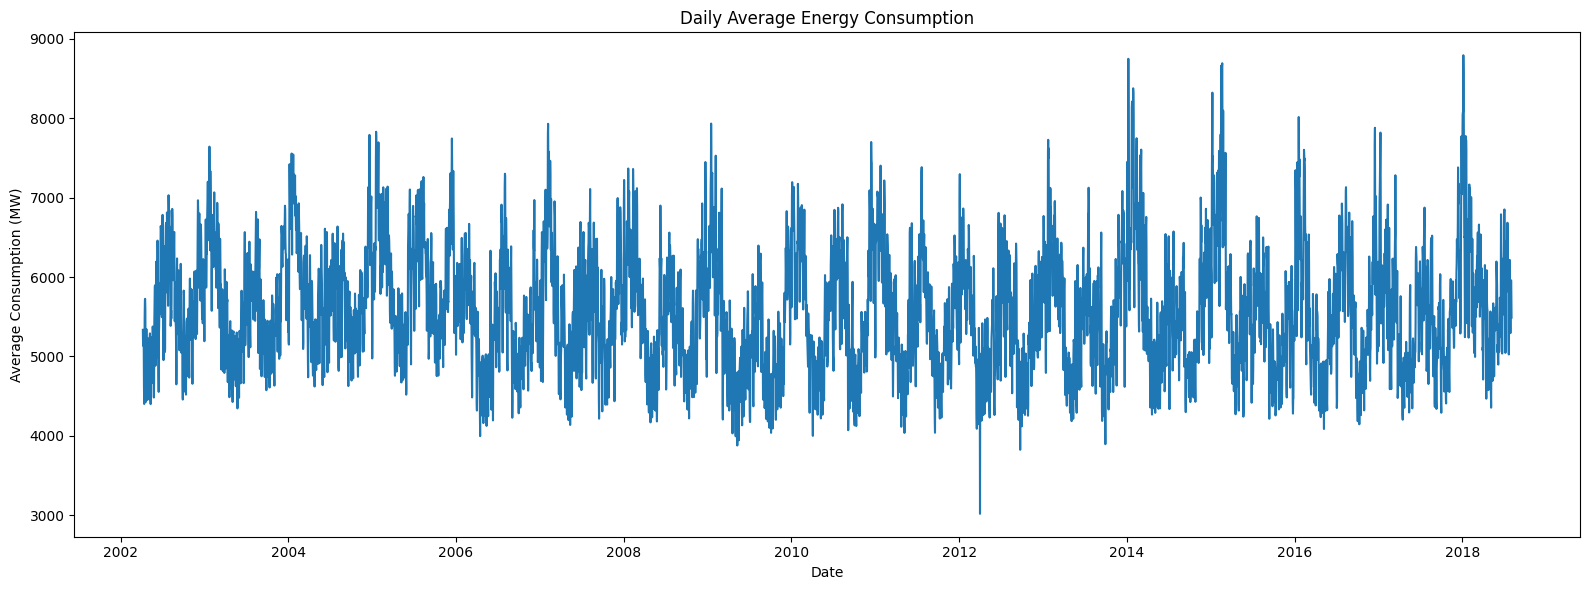

In [ ]:
daily_avg = (
    df.set_index("Datetime")["PJMW_MW"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_avg.index,
    daily_avg.values
)

plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Consumption (MW)")

plt.tight_layout()
plt.show()


#### INFERENCE:
Daily consumption shows substantial short-term fluctuations throughout the period. The series repeatedly rises and falls, with occasional high peaks and low values, indicating strong daily variability and recurring patterns in energy demand.

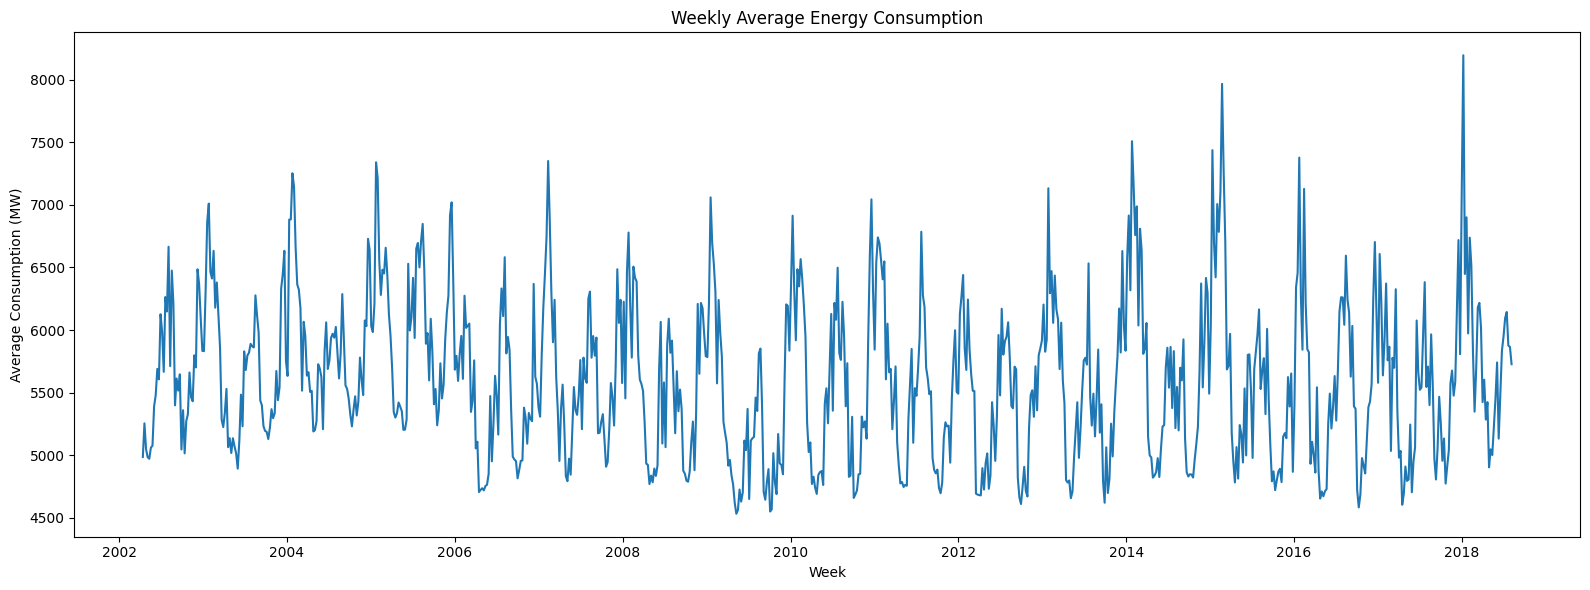

In [ ]:
weekly_avg = (
    df.set_index("Datetime")["PJMW_MW"]
    .resample("W")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    weekly_avg.index,
    weekly_avg.values
)

plt.title("Weekly Average Energy Consumption")
plt.xlabel("Week")
plt.ylabel("Average Consumption (MW)")

plt.tight_layout()
plt.show()

#### INFERENCE:
Weekly consumption also shows recurring fluctuations, with regular peaks and troughs. The overall level remains relatively stable across the years, suggesting repeating weekly patterns rather than a strong long-term trend.

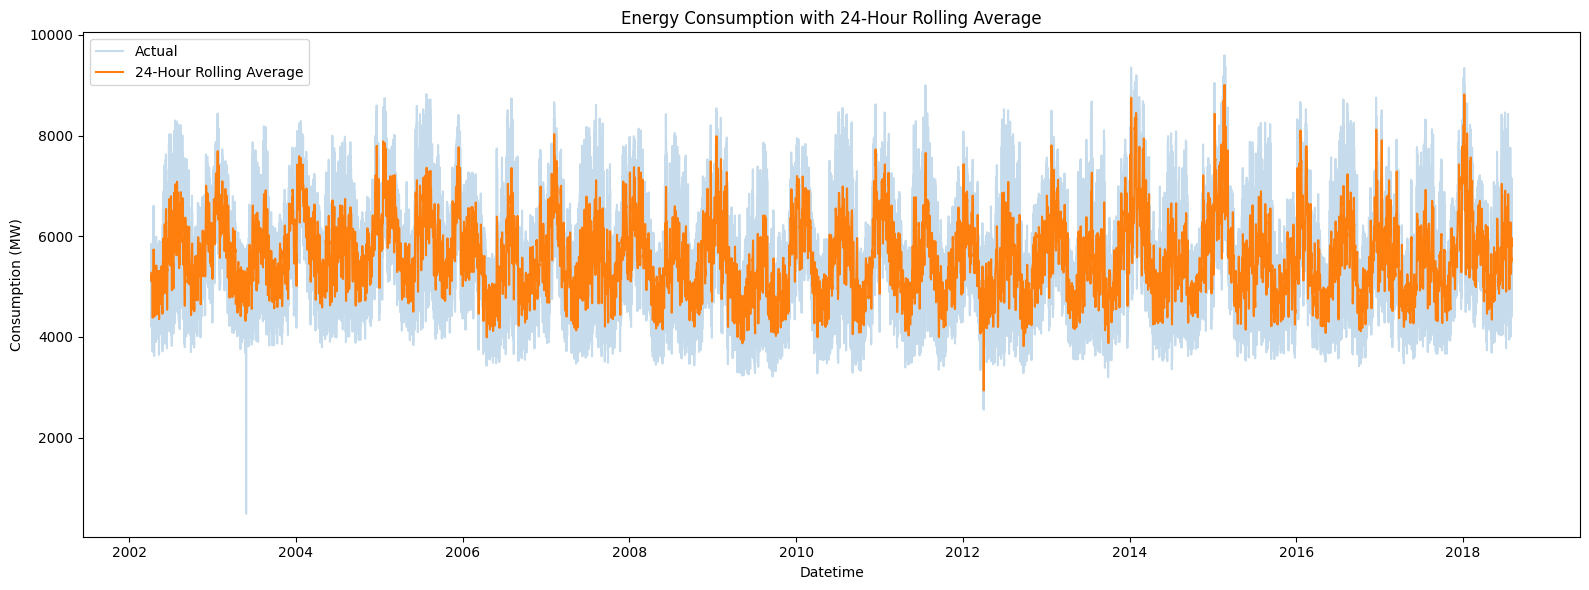

In [176]:
# Creating leakage-safe rolling averages for visualization

rolling_24h_plot = (
    df["PJMW_MW"]
    .shift(1)
    .rolling(24)
    .mean()
)

rolling_7d_plot = (
    df["PJMW_MW"]
    .shift(1)
    .rolling(168)
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    df["Datetime"],
    df["PJMW_MW"],
    alpha=0.25,
    label="Actual"
)

plt.plot(
    df["Datetime"],
    rolling_24h_plot,
    label="24-Hour Rolling Average"
)

plt.title("Energy Consumption with 24-Hour Rolling Average")
plt.xlabel("Datetime")
plt.ylabel("Consumption (MW)")
plt.legend()

plt.tight_layout()
plt.show()

#### INFERENCE:
The 24-hour rolling average smooths the short-term fluctuations in actual energy consumption. It clearly reveals the underlying consumption pattern while reducing the effect of individual hourly peaks and drops. This can be useful for identifying the general trend before forecasting.

In [ ]:
df["Lag_1_Hour"] = df["PJMW_MW"].shift(1)
df["Lag_24_Hours"] = df["PJMW_MW"].shift(24)
df["Lag_48_Hours"] = df["PJMW_MW"].shift(48)
df["Lag_168_Hours"] = df["PJMW_MW"].shift(168)

lag_columns = [
    "PJMW_MW",
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours"
]

print("\nLag Correlations:")
display(
    df[lag_columns].corr()
)



Lag Correlations:


,PJMW_MW,Lag_1_Hour,Lag_24_Hours,Lag_48_Hours,Lag_168_Hours
PJMW_MW,1.000000,0.974691,0.877210,0.750437,0.759371
Lag_1_Hour,0.974691,1.000000,0.860024,0.732817,0.737791
Lag_24_Hours,0.877210,0.860024,1.000000,0.877198,0.719295
Lag_48_Hours,0.750437,0.732817,0.877198,1.000000,0.673040
Lag_168_Hours,0.759371,0.737791,0.719295,0.673040,1.000000


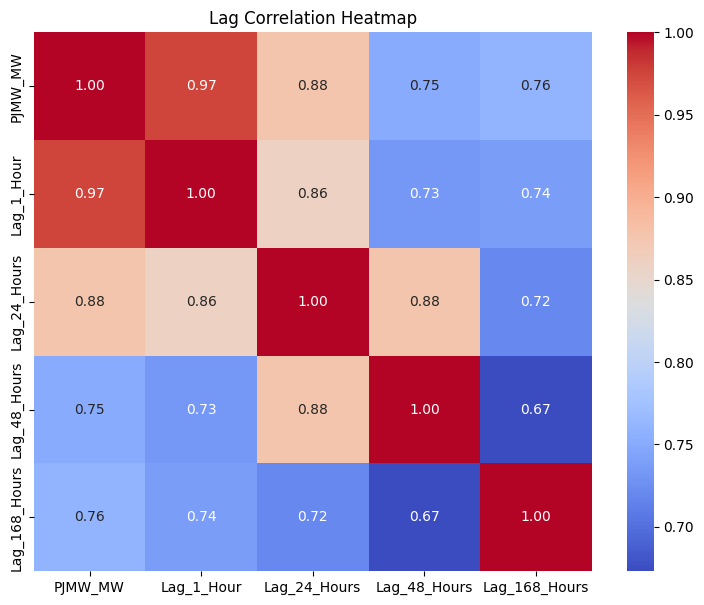

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    df[lag_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Lag Correlation Heatmap")

plt.show()



#### INFERENCE:
The heatmap shows strong positive correlations between current consumption and lagged consumption. The correlation is highest for shorter lags, such as 1 hour (0.97), and gradually decreases for longer lags, reaching around 0.76 at 168 hours. This indicates strong temporal dependence and suggests that previous energy consumption values can be useful predictors for forecasting.

In [ ]:
#Final Feature Selection.
features = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "Day_of_Week",
    "Quarter",
    "Week",
    "Weekend",
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

X = df[features]
y = df["PJMW_MW"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (143034, 14)
Target shape: (143034,)


In [175]:
# Chronological train-test split

train_size = int(len(df) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining period:")
print(df["Datetime"].iloc[:train_size].min())
print("to")
print(df["Datetime"].iloc[train_size - 1])

print("\nTesting period:")
print(df["Datetime"].iloc[train_size])
print("to")
print(df["Datetime"].iloc[-1])

Training data: (114427, 14)
Testing data: (28607, 14)

Training period:
2002-04-08 02:00:00
to
2015-04-28 22:00:00

Testing period:
2015-04-28 23:00:00
to
2018-08-03 00:00:00


#### Scaling the Features.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (114427, 14)
Scaled testing shape: (28607, 14)
